In [13]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('/Users/vedharai/hr-attrition-predictor/data/hr_clean.csv')

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

undersampler = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)
print(y_resampled.value_counts())

Attrition
0    198
1    198
Name: count, dtype: int64


/Users/vedharai/hr-attrition-predictor/venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vedharai/hr-attrition-predictor/venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [14]:
from sklearn.metrics import classification_report

resampled_rf = RandomForestClassifier(max_depth=3, min_samples_leaf=10, n_estimators=100, class_weight='balanced', random_state=42)
resampled_rf.fit(X_resampled, y_resampled)
rs_predictions = resampled_rf.predict(X_test)
print(classification_report(y_test, rs_predictions))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       255
           1       0.32      0.56      0.41        39

    accuracy                           0.78       294
   macro avg       0.62      0.69      0.64       294
weighted avg       0.84      0.78      0.81       294



<Axes: xlabel='Importance', ylabel='Feature'>

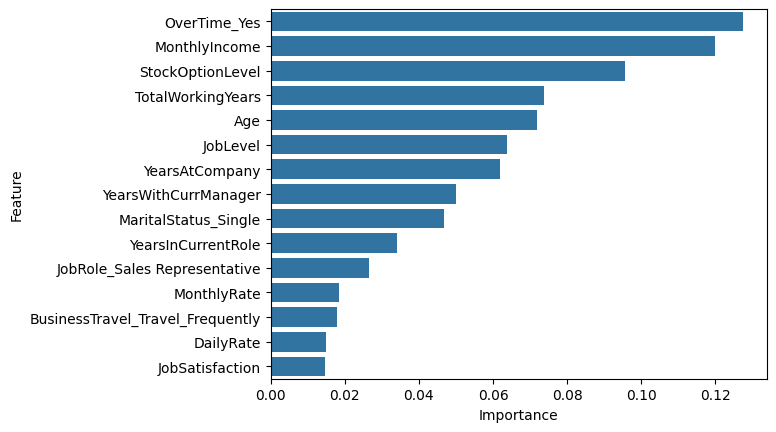

In [18]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': resampled_rf.feature_importances_
})

top_features = importance_df.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x ='Importance', y='Feature', orient='h', data=top_features)


Attrition is largely driven by overwork, low pay, low financial incentives, and being early in your careernot just job satisfaction